## Import Libraries

In [47]:
import numpy as np
import pandas as pd
from alpha_vantage.timeseries import TimeSeries
import torch
from torch.optim import Adam
import matplotlib.pyplot as plt

## Load the Data

The data source is the free alpha vantage.

In [50]:
# Alpha Vantage API key
api_key = 'QGP0PK7EO1AODNO1'
# Initialize Alpha Vantage API client
ts = TimeSeries(key=api_key, output_format='pandas')
# List of assets
assets = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA', 'NVDA', 'SPY', 'GLD', 'AGG']


To fecth, adjust, clean data and remove any missing value rows

In [51]:
# Fetch historical daily adjusted close prices
data_frames = []
for symbol in assets:
    data, meta_data = ts.get_daily(symbol=symbol, outputsize='compact')  # Use "compact" for smaller data
    print(data.tail())
    if '5. adjusted close' in data.columns:
        adjusted_close = data['5. adjusted close']
    else:
        adjusted_close = data['4. close']  # Fallback to regular close price
    data.name = symbol
    data_frames.append(data)

# Combine all assets into a single DataFrame
data = pd.concat(data_frames, axis=1).sort_index()
data = data.loc['2020-01-01':]  # Filter data from 2020 onwards
data = data.dropna()  # Remove any missing data

# Calculate daily returns
returns = data.pct_change().dropna()

ValueError: Thank you for using Alpha Vantage! Our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.

Since I will be using pytorch, this requires sending the data to a tensor

Additionally, defining some key analysis values
- annualized risk free rate of 0.01
- define a portfolio performace function which gives us return and risk
- define a function which returns the negetive sharp ratio


In [31]:
# Convert data to tensors
mean_returns = torch.tensor(returns.mean().values, dtype=torch.float32)
cov_matrix = torch.tensor(returns.cov().values, dtype=torch.float32)
risk_free_rate = 0.01  # Annualized risk-free rate

In [32]:
# Portfolio performance calculation
def portfolio_performance(weights, mean_returns, cov_matrix):
    portfolio_return = torch.dot(weights, mean_returns)
    portfolio_risk = torch.sqrt(torch.matmul(weights.T, torch.matmul(cov_matrix, weights)))
    return portfolio_return, portfolio_risk


In [33]:
# Negative Sharpe Ratio (objective function to minimize)
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    portfolio_return, portfolio_risk = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk
    return -sharpe_ratio

## Optimize the Portfolio

In [ ]:
# Ensure consistency
num_assets = len(assets)
returns = data.pct_change().dropna()
mean_returns = torch.tensor(returns.mean().values[:num_assets], dtype=torch.float32)
cov_matrix = torch.tensor(returns.cov().values[:num_assets, :num_assets], dtype=torch.float32)

# Initialize weights
weights = torch.randn(num_assets, requires_grad=True, dtype=torch.float32)

# Optimizer
optimizer = Adam([weights], lr=0.01)

# Optimization loop
num_iterations = 500
for i in range(num_iterations):
    optimizer.zero_grad()
    
    # Calculate loss (negative Sharpe Ratio)
    loss = negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate)
    loss.backward()
    optimizer.step()

    # Normalize weights
    with torch.no_grad():
        weights.data.clamp_(min=0)  # No short selling
        weights.data /= weights.data.sum()  # Normalize weights

    if i % 50 == 0:
        print(f"Iteration {i}: Loss (Negative Sharpe) = {loss.item()}")

# Final weights
optimal_weights = weights.detach().numpy()
print("Optimal Portfolio Weights:", optimal_weights)


Iteration 0: Loss (Negative Sharpe) = 0.11816996335983276
Iteration 50: Loss (Negative Sharpe) = 0.35967233777046204
Iteration 100: Loss (Negative Sharpe) = 0.35891154408454895
Iteration 150: Loss (Negative Sharpe) = 0.35878607630729675
Iteration 200: Loss (Negative Sharpe) = 0.3587740659713745
Iteration 250: Loss (Negative Sharpe) = 0.358776330947876
Iteration 300: Loss (Negative Sharpe) = 0.3587791919708252
Iteration 350: Loss (Negative Sharpe) = 0.3587813973426819
Iteration 400: Loss (Negative Sharpe) = 0.35878294706344604
Iteration 450: Loss (Negative Sharpe) = 0.3587843179702759
Optimal Portfolio Weights: [0.25009537 0.24937584 0.25037283 0.250156  ]


## Visualize

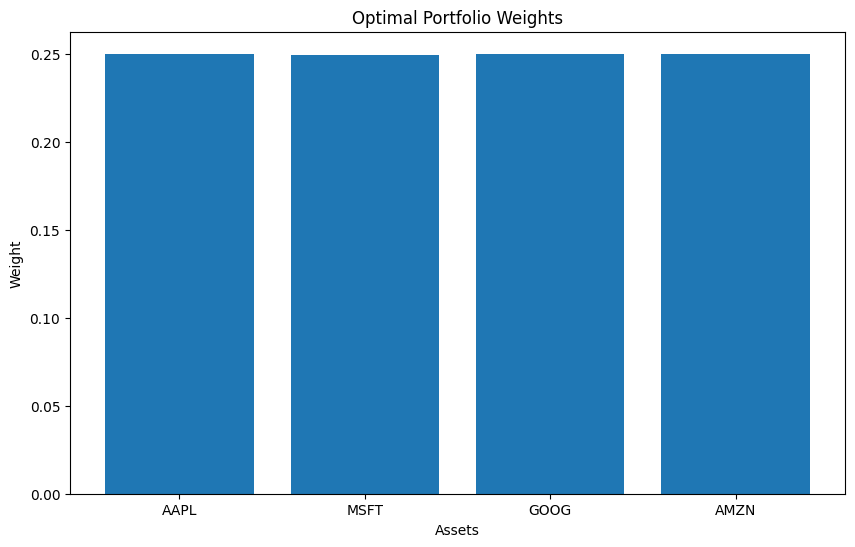

In [ ]:
# Visualize weights
plt.figure(figsize=(10, 6))
plt.bar(assets, optimal_weights)
plt.title('Optimal Portfolio Weights')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.show()


## Evaluate

In [36]:
# Calculate final portfolio performance
final_return, final_risk = portfolio_performance(torch.tensor(optimal_weights), mean_returns, cov_matrix)
sharpe_ratio = (final_return - risk_free_rate) / final_risk

print(f"Portfolio Return: {final_return.item():.2f}")
print(f"Portfolio Risk: {final_risk.item():.2f}")
print(f"Sharpe Ratio: {sharpe_ratio.item():.2f}")


Portfolio Return: 0.00
Portfolio Risk: 0.03
Sharpe Ratio: -0.36
